"""
Workflow:
---------
1. Data Understanding
2. EDA
3. Train / Validation / Test Split
4. Preprocessing
5. Baseline Model
6. Validation Metrics
7. Cross Validation
8. Hyperparameter Discussion
9. Validation Re-Evaluation
10. Train vs Validation Check
11. Linear Regression Specific Validations
12. Final Model Freeze
13. One-Time Test Evaluation
14. Interpretation
15. Deployment Readiness Check
"""


In [ ]:
# IMPORTS 

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import statsmodels.api as sm
from scipy.stats import (shapiro,jarque_bera)
import scipy.stats as stats
from statsmodels.stats.diagnostic import (het_breuschpagan)
from statsmodels.stats.stattools import (durbin_watson)
from statsmodels.stats.outliers_influence import (variance_inflation_factor)

In [ ]:
# ============================================================
# STEP 1 : DATA UNDERSTANDING
# ============================================================

housing = fetch_california_housing()
df = pd.DataFrame(housing.data,columns=housing.feature_names)
df["Target"] = housing.target
df.head()
df.info()
df.describe()

# Why info()?
# -> Understand datatypes and null values.
# Why describe()?
# -> Understand distributions and scale.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64
0
              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
Target      0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

            Latitude  Longitude    Target  
MedInc     -0.079809  -0.0

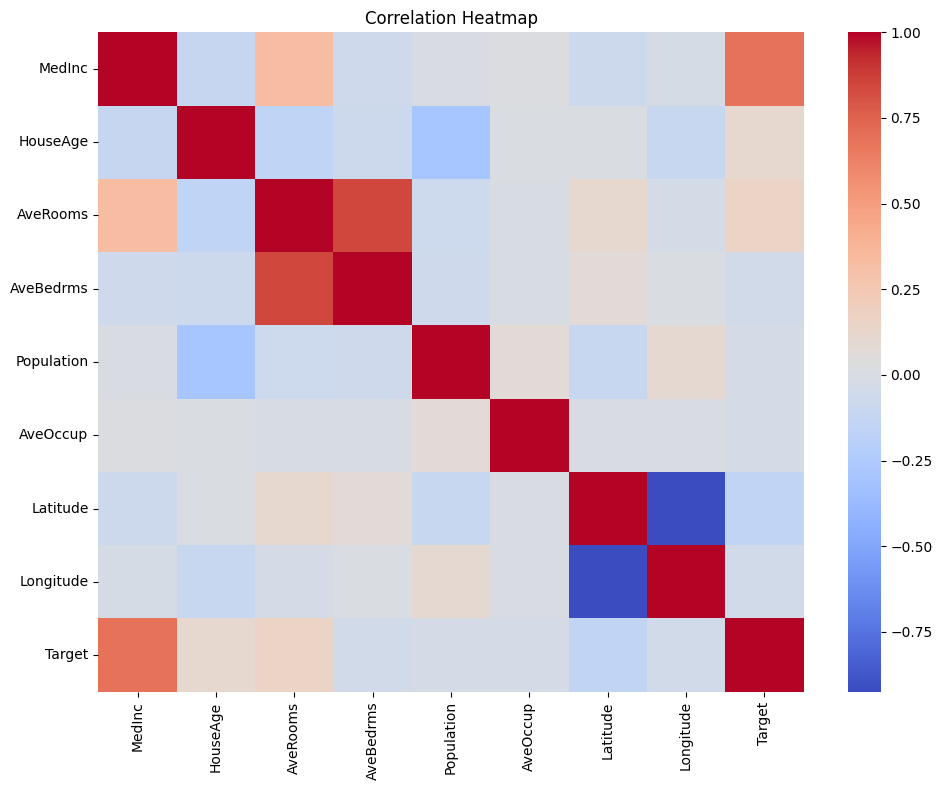

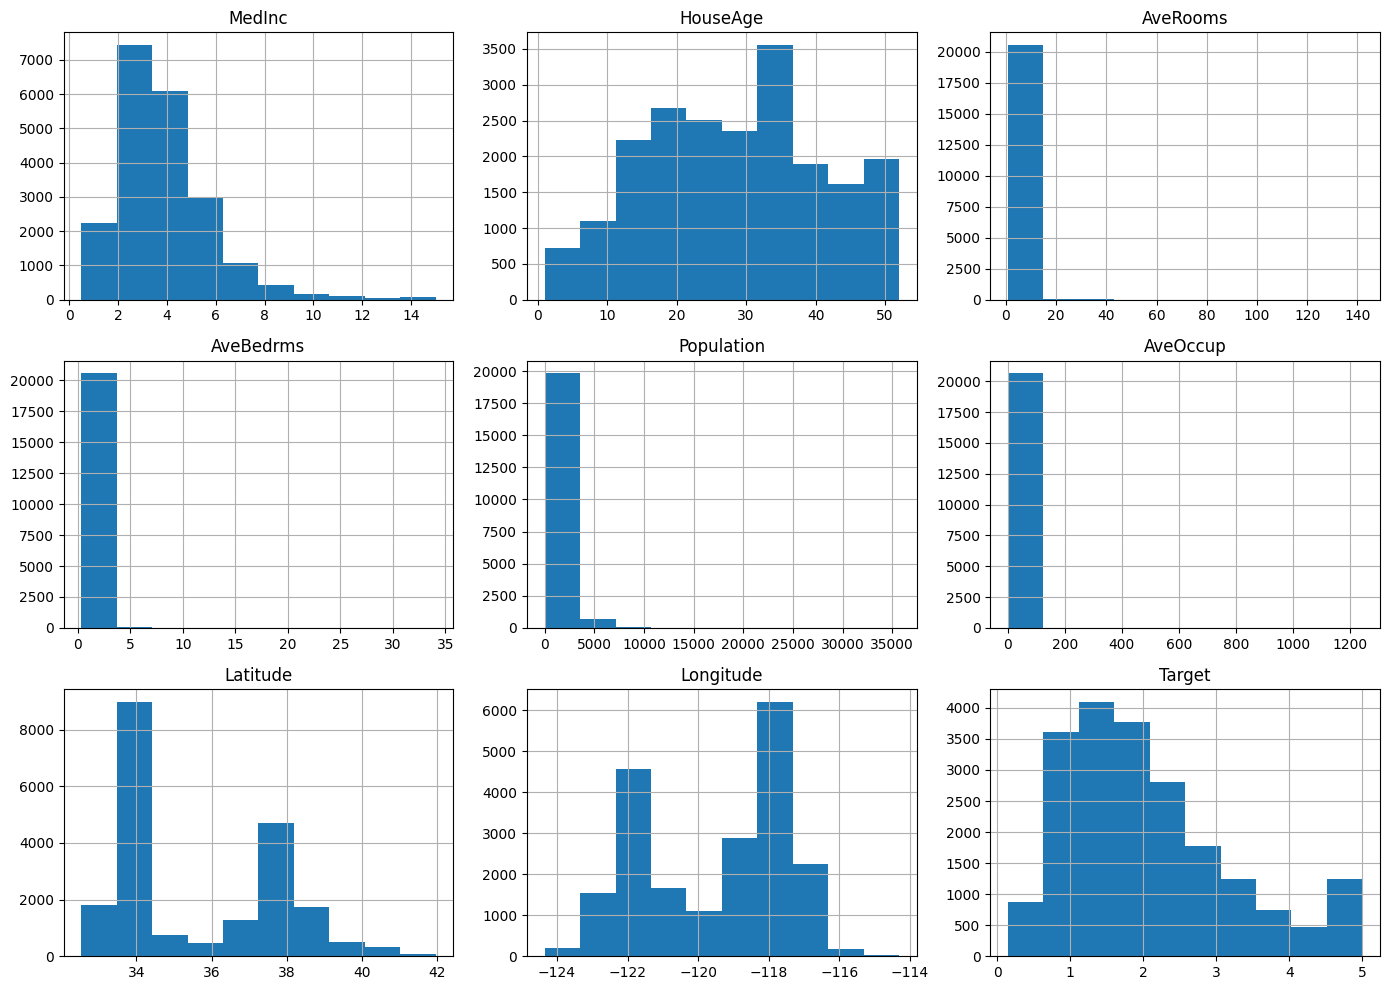

In [6]:
# ============================================================
# STEP 2 : EDA
# ============================================================

print(df.isnull().sum())
print(df.duplicated().sum())
print(df.corr())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

# Why check correlation?
# -> Detect relationships and multicollinearity.
# Why histogram?
# -> Understand distribution and skewness.

In [7]:
# ============================================================
# STEP 3 : TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X = df.drop("Target", axis=1)
y = df["Target"]
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.15,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.1765,random_state=42)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

# Why not train-test only?
# Validation is used for model selection.
# Test is used for final unbiased evaluation.

Train Shape: (14447, 8)
Validation Shape: (3097, 8)
Test Shape: (3096, 8)


In [8]:
# ============================================================
# STEP 4 : PREPROCESSING
# ============================================================

# We use Pipeline.
# Benefits:1. Cleaner Code
# 2. Prevents Leakage
# 3. Works with CV/GridSearchCV
# 4. Production Friendly

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression(fit_intercept=True,n_jobs=-1))
])

# Why fit scaler only on training data?
# To prevent DATA LEAKAGE.
# Pipeline handles this automatically.


In [9]:
# ============================================================
# STEP 5 : BASELINE MODEL
# ============================================================

pipe.fit(X_train,y_train)

# Important Parameters:
# fit_intercept
# positive
# n_jobs


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1


In [11]:
# ============================================================
# STEP 6 : VALIDATION check on validation data with base model
# ============================================================

y_pred = pipe.predict(X_val)
print("mae: ",mean_absolute_error(y_val,y_pred))
mse = mean_squared_error(y_val,y_pred)
print("mse: ",mse)
print("rmse: ",np.sqrt(mse))
r2 = r2_score(y_val,y_pred)
print("r2 score: ",r2)
n = len(y_val)
p = X_val.shape[1]
adj_r2 = 1 - (
    (1-r2)*(n-1)
)/(n-p-1)
print("adj_r2: ",adj_r2)

mae:  0.5308022995403732
mse:  0.5158242793925503
rmse:  0.7182090777709165
r2 score:  0.614434518430838
adj_r2:  0.6134356441262547


In [ ]:
# ============================================================
# STEP 7 : CROSS VALIDATION
# ============================================================
"""
Cross-validation is used for model selection and hyperparameter tuning. 
If the test set participates in cross-validation, information from the test distribution leaks into model development, 
resulting in an overly optimistic estimate of performance. 
Therefore, cross-validation is performed only on the training data, 
while the test set is kept completely unseen and used exactly once for final evaluation.
"""
cv_scores = cross_val_score(pipe,X_train,y_train,cv=5,scoring="r2",n_jobs=-1)

print("CV Scores:", cv_scores)
print("CV Mean :", cv_scores.mean())
print("CV Std  :", cv_scores.std())

# Low CV Std
# -> Stable model

CV Scores: [0.62141563 0.60059001 0.59099297 0.62478189 0.57496932]
CV Mean : 0.6025499638254941
CV Std  : 0.018699036958004296


# ============================================================
# STEP 8 : HYPERPARAMETER DISCUSSION
# ============================================================

print("""
Linear Regression has very few meaningful hyperparameters.

Performance usually improves through:

1. Feature Engineering
2. Outlier Treatment
3. Feature Selection
4. Regularization (Ridge/Lasso)
""")

In [13]:
# ============================================================
# STEP 9 : VALIDATION RE-EVALUATION
# ============================================================

print("Validation R2:", r2)

Validation R2: 0.614434518430838


In [15]:
# ============================================================
# STEP 10 : TRAIN VS VALIDATION CHECK
# ============================================================

train_pred = pipe.predict(X_train)
train_r2 = r2_score(y_train,train_pred)
val_r2 = r2_score(y_val,y_pred)
print("training data r2 score: ", train_r2)
print("validation data r2 score: ", val_r2)
# Large gap?
# -> Overfitting


training data r2 score:  0.6075883268839104
validation data r2 score:  0.614434518430838


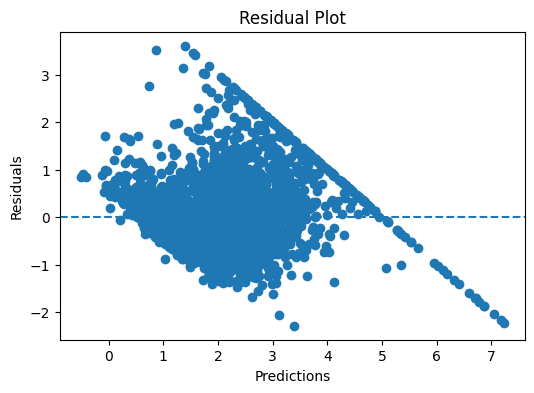

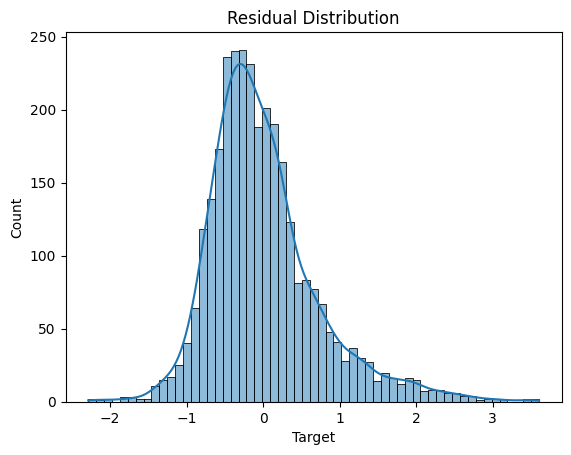

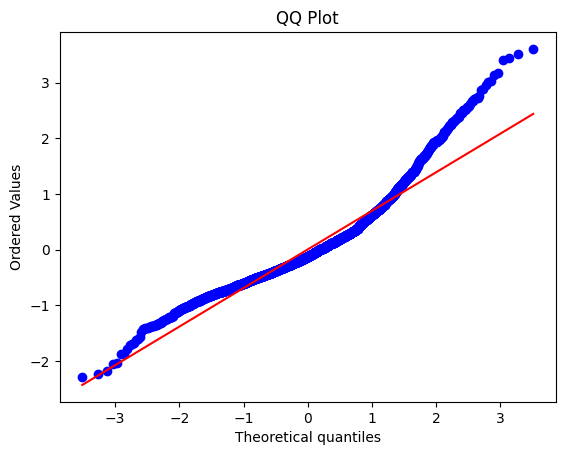

shapiro_stat values is 0.9305904988098352 and shapiro_p values is 1.0417635432952001e-35

Jarque Bera
jb_stat values is 1424.7816075599155 and jb_p values is 4.09831145319477e-310
ols:  <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000002ABCAC100D0>
bp:  (np.float64(1757.0041975852641), np.float64(0.0), np.float64(249.87820129842865), np.float64(0.0))
      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654

Top 10 Cook's Distance
7805     6.884240
6995     5.893580
14031    1.876644
14179    0.169707
11799    0.101218
7702     0.046831
9524     0.036966
12666    0.031331
1036     0.017184
12450    0.017033
dtype: float64


In [17]:
# ============================================================
# STEP 11 : LINEAR REGRESSION SPECIFIC VALIDATIONS
# ============================================================

# ------------------------------------------------------------
# Residual Analysis
# ------------------------------------------------------------

residuals = y_val - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

# Good Sign:
# Random cloud around zero

# ------------------------------------------------------------
# Normality Check
# ------------------------------------------------------------

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

stats.probplot(residuals,dist="norm",plot=plt)
plt.title("QQ Plot")
plt.show()

shapiro_stat, shapiro_p = shapiro(residuals.sample(min(5000, len(residuals)),random_state=42))
print(f"shapiro_stat values is {shapiro_stat} and shapiro_p values is {shapiro_p}")
jb_stat, jb_p = jarque_bera(residuals)
print("\nJarque Bera")
print(f"jb_stat values is {jb_stat} and jb_p values is {jb_p}")

# ------------------------------------------------------------
# OLS MODEL FOR DIAGNOSTICS
# ------------------------------------------------------------

X_train_const = sm.add_constant(X_train)
ols = sm.OLS(y_train,X_train_const).fit()
print("ols: ",ols)
# ------------------------------------------------------------
# Homoscedasticity
# ------------------------------------------------------------

bp = het_breuschpagan(ols.resid,X_train_const)
print("bp: ", bp)
# H0 = Homoscedasticity
# p > 0.05
# -> Good Sign

# ------------------------------------------------------------
# Independence
# ------------------------------------------------------------

dw = durbin_watson(ols.resid)
# Ideal ≈ 2

# ------------------------------------------------------------
# Multicollinearity
# ------------------------------------------------------------

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print(vif_df)

# Rule:
# VIF < 5  Good
# VIF >10  Severe Multicollinearity

# ------------------------------------------------------------
# Cook's Distance
# ------------------------------------------------------------

influence = ols.get_influence()
cooks = influence.cooks_distance[0]
print("\nTop 10 Cook's Distance")
print(pd.Series(cooks).sort_values(ascending=False).head(10))

# ============================================================
# STEP 12 : FINAL MODEL FREEZE
# ============================================================

final_model = pipe


In [18]:
# ============================================================
# STEP 13 : ONE-TIME TEST EVALUATION
# ============================================================
final_model = pipe
test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test,test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test,test_pred))
test_r2 = r2_score(y_test,test_pred)
n = len(y_test)
p = X_test.shape[1]

test_adj_r2 = 1 - (
    (1-test_r2)*(n-1)
)/(n-p-1)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2  :", test_r2)
print("Test Adj R2:", test_adj_r2)


Test MAE : 0.5354164211349082
Test RMSE: 0.7328971647620259
Test R2  : 0.5901296847586108
Test Adj R2: 0.5890675005921284


In [21]:
# ============================================================
# STEP 14 : INTERPRETATION
# ============================================================

model = final_model.named_steps["model"]

coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_}).sort_values(by="Coefficient",ascending=False)
print(model.intercept_)
print(ols.summary())

# sklearn -> prediction oriented
# statsmodels -> statistical inference

2.0629892621305457
                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2794.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:37:31   Log-Likelihood:                -15827.
No. Observations:               14447   AIC:                         3.167e+04
Df Residuals:                   14438   BIC:                         3.174e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.5303      0.781 

In [22]:
# ============================================================
# STEP 15 : DEPLOYMENT READINESS CHECK
# ============================================================

print("CV Mean      :", cv_scores.mean())
print("Validation R2:", val_r2)
print("Test R2      :", test_r2)

# Healthy:
#
# CV ≈ Validation ≈ Test

CV Mean      : 0.6025499638254941
Validation R2: 0.614434518430838
Test R2      : 0.5901296847586108


In [23]:
# ============================================================
# SAMPLE PREDICTION
# ============================================================

sample = X_test.iloc[[0]]
prediction = final_model.predict(sample)
print("Prediction:", prediction[0])
print("Actual    :", y_test.iloc[0])

Prediction: 0.735268277279693
Actual    : 0.477


# ============================================================
# INTERVIEW QUESTIONS
# ============================================================

"""
1. Assumptions of Linear Regression?

   - Linearity
   - Independence
   - Normality of residuals
   - Homoscedasticity
   - No Multicollinearity
2. Difference between R2 and Adjusted R2?
3. Why Adjusted R2?
4. What is VIF?
5. What is Multicollinearity?
6. What is Heteroscedasticity?
7. What is Breusch-Pagan Test?
8. What is Durbin-Watson?
9. What is Cook's Distance?
10. Why fit scaler only on training data?
11. What is Data Leakage?
12. Why Train / Validation / Test split?
13. Why not use Test data during tuning?
14. Difference between OLS and sklearn LinearRegression?
15. Why Linear Regression is sensitive to outliers?
16. Why use Cross Validation?
17. Why Pipeline?
18. What does fit_intercept do?
19. When should Ridge/Lasso be preferred?
20. What does a coefficient represent?
"""